<a href="https://colab.research.google.com/github/ManthanGarg-1234/AIML-CLASSWORK/blob/main/10_Aug_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

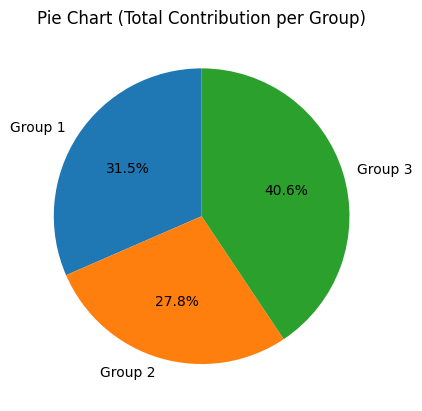

In [50]:
import matplotlib.pyplot as plt


data = [ [10,12,14,15,18,20,22],
        [8,9,11,13,17,19,21],
    [14, 16, 18, 20, 23, 25, 27] ]

# Aggregate data by summing the values in each group
group_sums = [sum(group) for group in data]
labels = ['Group 1', 'Group 2', 'Group 3']

# Create the pie chart
plt.pie(group_sums, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Pie Chart (Total Contribution per Group)")
plt.show()


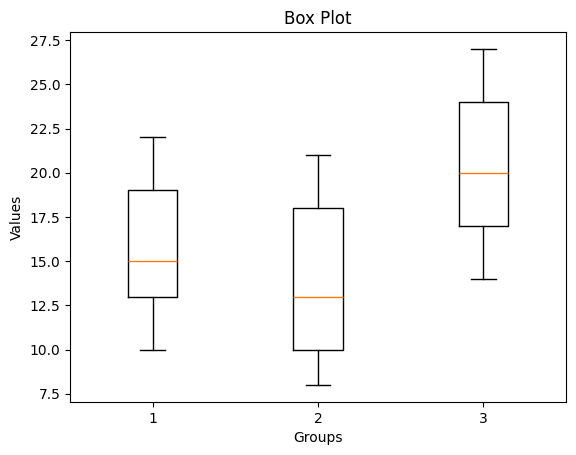

In [51]:
import matplotlib.pyplot as plt

data = [ [10,12,14,15,18,20,22],
        [8,9,11,13,17,19,21],
        [14,16,18,20,23,25,27] ]

plt.boxplot(data)
plt.xlabel("Groups")
plt.ylabel("Values")
plt.title("Box Plot")
plt.show()

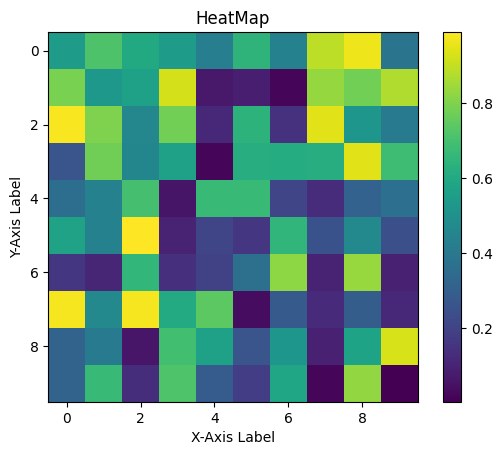

In [52]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
data = np.random.rand(10,10)

plt.imshow(data,cmap='viridis',interpolation='nearest')

plt.colorbar()
plt.xlabel("X-Axis Label")
plt.ylabel("Y-Axis Label")
plt.title("HeatMap")
plt.show()

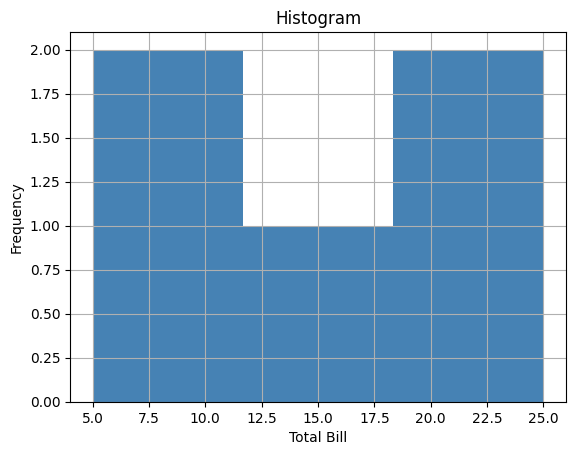

In [53]:
import matplotlib.pyplot as plt

x=[5,10,15,20,25]
plt.hist(x,bins=3,color='steelblue')
plt.title("Histogram")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.grid()
plt.show()

## Resources

Here are some helpful resources for further exploration of `matplotlib` and data visualization:

*   **Matplotlib Official Documentation:** The official documentation is a comprehensive resource for all `matplotlib` functionalities. [https://matplotlib.org/stable/contents.html](https://matplotlib.org/stable/contents.html)

*   **Matplotlib Gallery:** A great place to find examples and inspiration for different plot types, including box plots, heatmaps, pie charts, and histograms. [https://matplotlib.org/stable/gallery/index.html](https://matplotlib.org/stable/gallery/index.html)

*   **Box Plot Documentation:** Learn more about customizing box plots. [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

*   **Heatmap (`imshow`) Documentation:** Explore options for creating and customizing heatmaps. [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

*   **Pie Chart Documentation:** Detailed information on pie chart customization. [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html)

*   **Histogram Documentation:** Understand the various parameters for histograms. [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)

## CSV Data Cleaning and Download

This section demonstrates how to load a CSV file (`data.csv`), clean its contents by replacing common missing value representations with a 'Default' string, and then provides a convenient link to download the cleaned data as a new CSV file.

### How it works:

1.  **`clean_and_default(val)` function**: A custom function is defined to identify various forms of missing data (e.g., 'None', 'null', 'NaN', empty strings) and replaces them with the string 'Default'. You can easily modify the `"Default"` string to any other placeholder you prefer.
2.  **Column Detection**: The code first reads only the header of the `data.csv` file to identify all column names. This ensures that the `clean_and_default` function is applied to every column.
3.  **Data Loading with Cleaning**: The `pd.read_csv` function is then used with a `converters` dictionary. This dictionary maps each column name to our `clean_and_default` function, applying the cleaning logic during the data loading process itself.
4.  **Download Link Generation**: The cleaned DataFrame (`df_cleaned`) is converted back into a CSV string. This string is then base64 encoded and embedded into an HTML link, allowing you to download the `cleaned_data_from_start.csv` directly from the notebook output.

In [54]:
import base64
import pandas as pd
from IPython.display import HTML

# 1. Custom function to clean inputs immediately at load time
def clean_and_default(val):
    val_str = str(val).strip()
    # Check against all variations of missing data
    if val_str in ["None", "none", "NONE", "null", "NULL", "Null", "NaN", "", "nan", "NaN"]:
        return "Default" # <-- Set your initial default text here
    return val_str

# 2. Peak into columns first to apply the default loader to all columns
preview_df = pd.read_csv("data.csv", nrows=0)
converters_dict = {col: clean_and_default for col in preview_df.columns}

# 3. Read the complete file applying defaults from the very start
df_cleaned = pd.read_csv("data.csv", converters=converters_dict)

# 4. Prepare download link
csv_data = df_cleaned.to_csv(index=False)
b64 = base64.b64encode(csv_data.encode()).decode()

download_filename = "cleaned_data_from_start.csv"
html_link = f'<a href="data:file/csv;base64,{b64}" download="{download_filename}" style="font-size:16px; font-weight:bold; color:#ff5722;">👉 Click Here to Download Cleaned CSV File</a>'

HTML(html_link)
